In [ ]:
import numpy as np
import pandas as pd

# Manejo de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Funciones error
from sklearn.metrics import mean_squared_error

# Modelos especificando lambda
from sklearn.linear_model import Ridge, Lasso

# Modelos de regresion con CV Folds para busaqueda de lambda
from sklearn.linear_model import LassoCV, RidgeCV

In [2]:
raw_data = pd.read_csv('./data/taller1.txt')
raw_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
y,1200.0,-0.166781,4.507987,-13.909392,-3.093138,-0.075897,2.733829,16.841996
V1,1200.0,0.021837,0.996187,-2.809775,-0.641328,0.009210,0.659820,3.241040
V2,1200.0,0.003478,0.981623,-3.047861,-0.652945,-0.004903,0.686442,3.390371
V3,1200.0,0.002994,1.007457,-3.129088,-0.643962,-0.024718,0.678011,3.421095
V4,1200.0,-0.018853,0.988009,-3.043135,-0.676762,0.018448,0.639679,3.445992
...,...,...,...,...,...,...,...,...
V4996,1200.0,-0.069813,0.995941,-3.092060,-0.756406,-0.067870,0.587994,2.919174
V4997,1200.0,0.019437,1.007602,-3.081198,-0.652676,0.038461,0.685863,3.919764
V4998,1200.0,0.048621,0.978025,-3.059535,-0.614155,0.032861,0.724150,3.441460
V4999,1200.0,-0.003119,1.017224,-3.424407,-0.686754,-0.013495,0.688465,3.610014


In [3]:
corr_matrix =raw_data.corr()

: 

: 

In [ ]:
lin_val = pd.melt(corr_matrix.reset_index(), id_vars='index', var_name='column', value_name='correlation')
lin_val = lin_val.rename(columns={'index': 'X1', 'column': 'X2'})
lin_val['correlation'] = lin_val['correlation'].abs()
(lin_val[(lin_val['correlation'] > 0.1) & (lin_val['X1'] != lin_val['X2'])]
    .drop_duplicates(subset=['correlation'], keep='first')
    .sort_values(by='correlation', ascending=False))

In [ ]:



raw_X, raw_y = raw_data.drop('y', axis = 1), raw_data['y']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(raw_X)
y_scaled = scaler.fit_transform(raw_y.values.reshape(-1, 1)).flatten()


# X, y are your features and target
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size= 1/6, random_state = 3003)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X = {'train': X_train_scaled, 'test': X_test_scaled}
y = {'train': y_train, 'test': y_test}


In [21]:
alpha_ridge = np.linspace(1e-3, 1e6, 50)
alpha_ridge = np.insert(alpha_ridge, 0, 0)
alpha_lasso = np.logspace(-3, 2, 50) 

mse_ridge = {'train': np.array([])
            ,'test' : np.array([])             
}

mse_lasso = {'train': np.array([])
            ,'test' : np.array([])             
}
def eval_model(model, X, y):
    model = model.fit(X['train'], y['train'])
    pred_train = model.predict(X['train'])
    pred_test = model.predict(X['test'])
    return mean_squared_error(y['train'], pred_train),mean_squared_error(y['test'], pred_test),

for alpha in alpha_ridge:
    model = Ridge(alpha = alpha, random_state = 3003)
    mse = eval_model(model, X, y)
    mse_ridge['train'] = np.append(mse_ridge['train'], mse[0])
    mse_ridge['test'] = np.append(mse_ridge['test'], mse[1])

for alpha in alpha_lasso:
    model =Lasso(alpha=alpha, random_state = 3003)
    mse = eval_model(model, X, y)
    mse_lasso['train'] = np.append(mse_lasso['train'], mse[0])
    mse_lasso['test'] = np.append(mse_lasso['test'], mse[1])

C:\Users\mange\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.94905e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


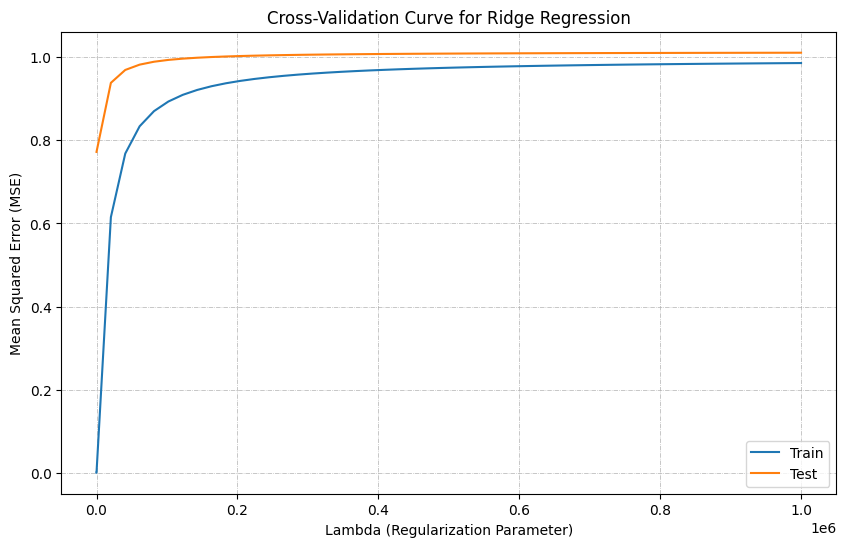

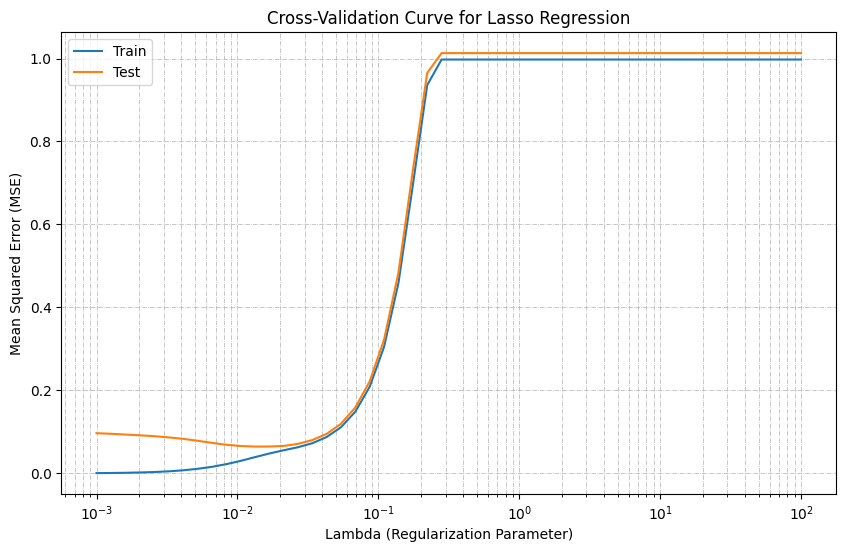

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.plot(alpha_ridge, mse_ridge['train'], label='Train')
plt.plot(alpha_ridge, mse_ridge['test'], label='Test')
#plt.yscale('log') # MSE can also be on a log scale for better visualization
plt.xlabel('Lambda (Regularization Parameter)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Cross-Validation Curve for Ridge Regression')
#plt.axvline(best_alpha, color='red', linestyle='--', label=f'Optimal Alpha: {best_alpha:.4f}')
plt.legend()
plt.grid(True, which='both', linestyle='-.', linewidth=0.5)
plt.show()

plt.figure(figsize=(10, 6))

plt.plot(alpha_lasso, mse_lasso['train'], label='Train')
plt.plot(alpha_lasso, mse_lasso['test'], label='Test')
plt.xscale('log') # Alpha is on a log scale
#plt.yscale('log') # MSE can also be on a log scale for better visualization
plt.xlabel('Lambda (Regularization Parameter)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Cross-Validation Curve for Lasso Regression')
#plt.axvline(best_alpha, color='red', linestyle='--', label=f'Optimal Alpha: {best_alpha:.4f}')
plt.legend()
plt.grid(True, which='both', linestyle='-.', linewidth=0.5)
plt.show()


In [ ]:



alpha_ridge = np.logspace(-9, -3, 50) 
alpha_lasso = np.logspace(-2, -1, 50) 

lasso_cv = LassoCV(alphas=alpha_lasso, cv=5, random_state=3003)
lasso_cv.fit(X['train'], y['train'])
best_alpha_lasso = lasso_cv.alpha_
ridge_cv = RidgeCV(alphas=alpha_ridge, cv=5)
ridge_cv.fit(X['train'], y['train'])
best_alpha_ridge = ridge_cv.alpha_
print(f'Optimal Alpha for Ridge Regression: {best_alpha_ridge:.4f}')
print(f'Optimal Alpha for Lasso Regression: {best_alpha_lasso:.4f}')



Optimal Alpha for Ridge Regression: 0.0000
Optimal Alpha for Lasso Regression: 0.0168


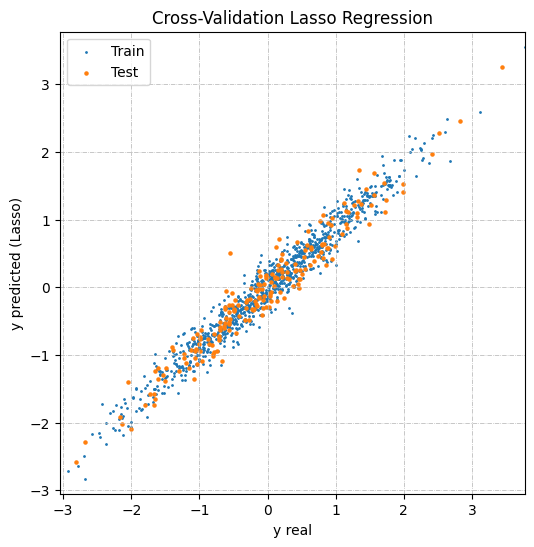

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(y['train'], lasso_cv.predict(X['train']), label='Train', s = 1)
plt.scatter(y['test'], lasso_cv.predict(X['test']), label='Test', s = 5)
#plt.yscale('log') # MSE can also be on a log scale for better visualization
plt.xlabel('y real')
plt.ylabel('y predicted (Lasso)')
plt.title('Cross-Validation Lasso Regression')
plt.xlim([min(y_scaled),max(y_scaled)])
plt.ylim([min(y_scaled),max(y_scaled)])
#plt.axvline(best_alpha, color='red', linestyle='--', label=f'Optimal Alpha: {best_alpha:.4f}')
plt.legend()
plt.grid(True, which='both', linestyle='-.', linewidth=0.5)
plt.show()



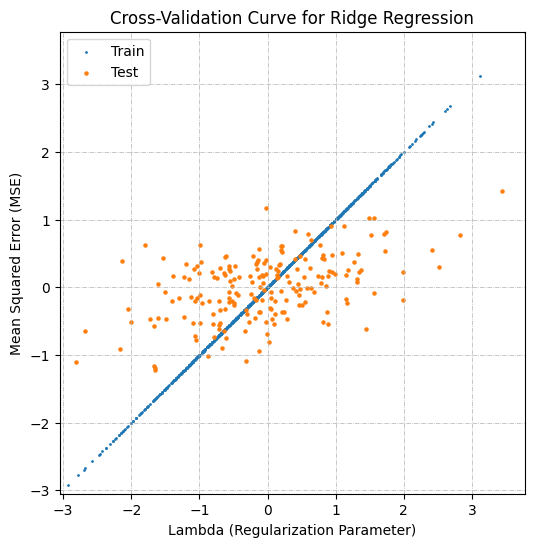

In [8]:

plt.figure(figsize=(6, 6))
plt.scatter(y['train'], ridge_cv.predict(X['train']), label='Train', s = 1)
plt.scatter(y['test'], ridge_cv.predict(X['test']), label='Test', s = 5)
#plt.yscale('log') # MSE can also be on a log scale for better visualization
plt.xlabel('Lambda (Regularization Parameter)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Cross-Validation Curve for Ridge Regression')
plt.xlim([min(y_scaled),max(y_scaled)])
plt.ylim([min(y_scaled),max(y_scaled)])
#plt.axvline(best_alpha, color='red', linestyle='--', label=f'Optimal Alpha: {best_alpha:.4f}')
plt.legend()
plt.grid(True, which='both', linestyle='-.', linewidth=0.5)
plt.show()

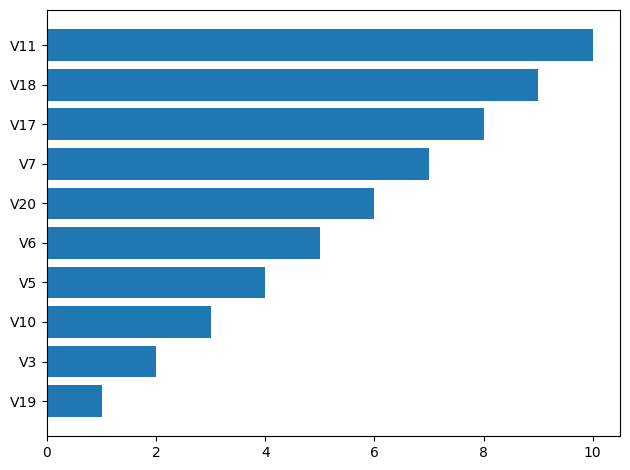

In [17]:
df_coef = (pd.DataFrame({'Variable': raw_X.columns, 'Coefficient' : lasso_cv.coef_, 'AbsCoef' : np.abs(lasso_cv.coef_)})
           .sort_values(by = 'AbsCoef', ascending = True))

df_coef = df_coef.tail(10)
df_coef['Rank'] = df_coef['AbsCoef'].rank(ascending = True)


plt.Figure()
plt.barh(df_coef['Variable'], df_coef['Rank'])
plt.tight_layout()
plt.show()

In [18]:
df_coef 

,Variable,Coefficient,AbsCoef,Rank
18,V19,0.202337,0.202337,1.0
2,V3,0.203486,0.203486,2.0
9,V10,0.204221,0.204221,3.0
4,V5,0.209328,0.209328,4.0
5,V6,0.209982,0.209982,5.0
19,V20,0.210217,0.210217,6.0
6,V7,0.211549,0.211549,7.0
16,V17,0.211802,0.211802,8.0
17,V18,0.212647,0.212647,9.0
10,V11,0.217267,0.217267,10.0


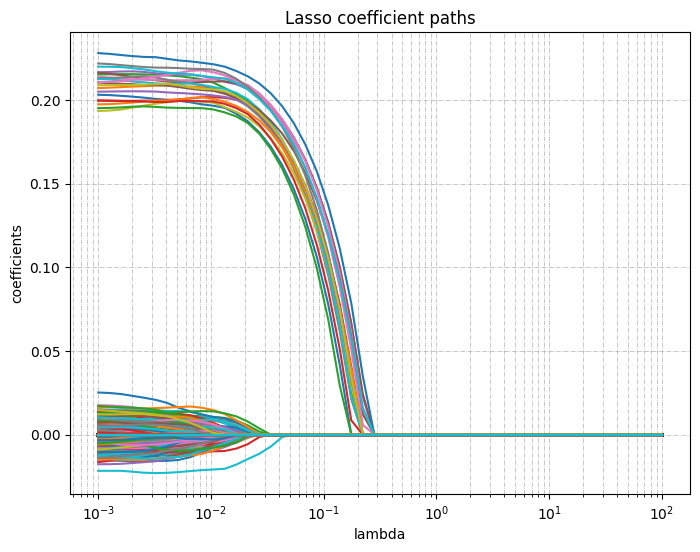

In [23]:
from sklearn.linear_model import lasso_path

alphas_lasso, coefs_lasso, _ = lasso_path(X['train'],y['train'], alphas = alpha_lasso)

plt.figure(figsize=(8,6))

for coef in coefs_lasso:
    plt.plot(alphas_lasso, coef)

plt.xscale('log')
plt.xlabel("lambda")
plt.ylabel("coefficients")
plt.title("Lasso coefficient paths")
plt.grid(True, which='both', linestyle='-.', linewidth=0.5)

plt.show()